# Four-source standard autoencoder


In [1]:
%matplotlib inline
import os, sys
from pathlib import Path
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')
PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT/'src'/'lss').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT/'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT/'src'))
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import numpy as np
import pandas as pd
import torch
from graph_utils import calc_p_ratio_rollout_sides, directional_side_indices_from_box
from lss.latent.experiment import evaluate_autoencoder_reconstruction_horizons, latent_experiment_cache_key, run_latent_experiment, seed_everything
from lss.latent.simulation import batch_delta_graphs, r2_score
from lss.plotting import PAPER_COLORS, apply_editorial_style, dataset_color, style_axes
from lss.utils import resolve_device
apply_editorial_style()
DEVICE = resolve_device('auto')


/home/alexz/Documents/course_project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 123
FORCE_TRAIN_AE = False
TRAIN_COUNTS = {'reid': 30, 'depablo_low_temp': 30, 'depablo_mixed_temp': 30, 'lj_noisy': 60}
VAL_COUNTS = {'reid': 30, 'depablo_low_temp': 30, 'depablo_mixed_temp': 30, 'lj_noisy': 30}
MAX_FRAMES_PER_SIM = 100
BATCH_GRAPHS = 32
LATENT_DIM = 6
HIDDEN_SIZE = 128
LATENT_TOKENS = 32
DATASETS = {
    'reid': ('Reid', PROJECT_ROOT/'data'/'reid_200_frames.pt'),
    'depablo_low_temp': ('de Pablo low-T', PROJECT_ROOT/'data'/'depablo-near-zero-temp.pt'),
    # 'depablo_mixed_temp': ('de Pablo mixed-T', PROJECT_ROOT/'data'/'depablo-10k-mix-temp.pt'),
    'lj_noisy': ('noisy LJ', PROJECT_ROOT/'data'/'lj-noisy-eps0.01-sigma1.0-cutoff1.122_200sims_200frames.pt'),
}
for _, path in DATASETS.values():
    assert path.is_file(), path
OUTPUT = PROJECT_ROOT/'notebooks'/'results'/'09_four_source_standard_ae_pca'
CACHE_DIR = OUTPUT/'cache'
CACHE_DIR.mkdir(parents=True, exist_ok=True)


In [3]:
source = {
    'dataset_name': '09 four-source standard AE',
    'source_name': '09 four-source standard AE',
    'label': '09 four-source standard AE',
    'path': str(DATASETS['reid'][1]),
    'dataset_mixture': [
        {
            'name': key, 'label': label, 'path': str(path),
            'train_count': TRAIN_COUNTS[key], 'val_count': VAL_COUNTS[key],
            'append_lj_indicator': True,
            # Live-only LJ relations: all pairs at spring-graph distance 2 or 3.
            'lj_max_graph_distance': 3 if key == 'lj_noisy' else None,
        }
        for key, (label, path) in DATASETS.items()
    ],
}
ae_config = {
    'model': 'attention', 'latent_dim': LATENT_DIM, 'latent_tokens': LATENT_TOKENS,
    'hidden_size': HIDDEN_SIZE, 'target_mode': 'normalized_delta',
    'node_feature_mode': 'normalized_delta', 'edge_feature_dim': 5,
    'max_train_frames_per_sim': MAX_FRAMES_PER_SIM, 'max_val_frames_per_sim': MAX_FRAMES_PER_SIM,
    'train_frame_skip': 1, 'val_frame_skip': 1,
    'max_epochs': 50, 'patience': 8, 'lr': 1e-4, 'weight_decay': 1e-5,
    # Ordinary shared-AE optimization: no Nash-MTL or other gradient arbitration.
    'mix_sources': True, 'balance_sources': False, 'gradient_method': 'mean',
}
config = {
    'ae_config': ae_config, 'dataset_name': source['dataset_name'],
    'split_seed': SEED, 'model_seed': SEED, 'device': str(DEVICE),
    'pos_dim': 2, 'batch_graphs': BATCH_GRAPHS, 'frame_skip': 1,
    'coordinate_normalization': 'position_normalization', 'edge_mode': 'compact_stored',
    'should_rollout': False, 'should_train_propagator': False,
    'force_train': FORCE_TRAIN_AE, 'cache_dir': str(CACHE_DIR),
    'cache_require_matching_config': True, 'early_stop_min_delta': 1e-5,
}
AE_CONFIG_HASH = latent_experiment_cache_key(source, config)
AE_CACHE = CACHE_DIR/f'latent_{AE_CONFIG_HASH}.pt'
print({'device': str(DEVICE), 'ae_cache': str(AE_CACHE), 'cached': AE_CACHE.is_file(), 'lj_max_graph_distance': 3})
seed_everything(SEED)
result = run_latent_experiment(source, config, device=DEVICE)
display(result['split_info'])
display(result['ae_history'].tail())


{'device': 'cuda', 'ae_cache': '/home/alexz/Documents/course_project/notebooks/results/09_four_source_standard_ae_pca/cache/latent_cd8d92300974ab08.pt', 'cached': False, 'lj_max_graph_distance': 3}



=== 09 four-source standard AE ===
          source                                                                                                 path  total  train  reserved_train_pool  val  test
            reid                                         /home/alexz/Documents/course_project/data/reid_200_frames.pt    102     30                   30   30    42
depablo_low_temp                                  /home/alexz/Documents/course_project/data/depablo-near-zero-temp.pt    200     30                   30   30   140
        lj_noisy /home/alexz/Documents/course_project/data/lj-noisy-eps0.01-sigma1.0-cutoff1.122_200sims_200frames.pt    200     60                   60   30   110
source-mixed AE coverage: {'reid': {'trajectories': 30, 'frames': 3000}, 'depablo_low_temp': {'trajectories': 30, 'frames': 3000}, 'lj_noisy': {'trajectories': 60, 'frames': 6000}}
autoencoder
ae 0001 train=0.479396 val=0.432372 stale=0
ae 0002 train=0.329871 val=0.404161 stale=0
ae 0003 train=0.311281 val=

,source,path,total,train,reserved_train_pool,val,test
0,reid,/home/alexz/Documents/course_project/data/reid...,102,30,30,30,42
1,depablo_low_temp,/home/alexz/Documents/course_project/data/depa...,200,30,30,30,140
2,lj_noisy,/home/alexz/Documents/course_project/data/lj-n...,200,60,60,30,110


,epoch,train_objective,val_objective,train_mse_norm,train_source_depablo_low_temp_reconstruction,train_source_lj_noisy_reconstruction,train_source_reid_reconstruction,val_mse_norm,val_source_reid_reconstruction,val_source_depablo_low_temp_reconstruction,val_source_lj_noisy_reconstruction,dataset,latent_dim,target_mode,hidden_size
12,13,0.199753,0.225508,0.199753,0.117612,0.300649,0.138928,0.225508,0.189425,0.144440,0.344879,09 four-source standard AE,6,normalized_delta,128
13,14,0.198142,0.228516,0.198142,0.116055,0.299037,0.137683,0.228516,0.190084,0.145908,0.351832,09 four-source standard AE,6,normalized_delta,128
14,15,0.196383,0.224238,0.196383,0.113821,0.296946,0.136523,0.224238,0.189544,0.138607,0.346784,09 four-source standard AE,6,normalized_delta,128
15,16,0.194716,0.224367,0.194716,0.111570,0.294538,0.135309,0.224367,0.190085,0.134755,0.350386,09 four-source standard AE,6,normalized_delta,128
16,17,0.192673,0.225856,0.192673,0.109697,0.292033,0.134721,0.225856,0.189340,0.137031,0.353002,09 four-source standard AE,6,normalized_delta,128


,source,frame,n,p_ratio_r2
0,depablo_low_temp,10,140,0.821
1,depablo_low_temp,20,140,0.912
2,depablo_low_temp,30,140,0.944
3,depablo_low_temp,40,140,0.963
4,depablo_low_temp,50,140,0.975
5,depablo_low_temp,60,140,0.983
6,depablo_low_temp,70,140,0.987
7,depablo_low_temp,80,140,0.987
8,depablo_low_temp,90,140,0.983
9,depablo_low_temp,100,140,0.977


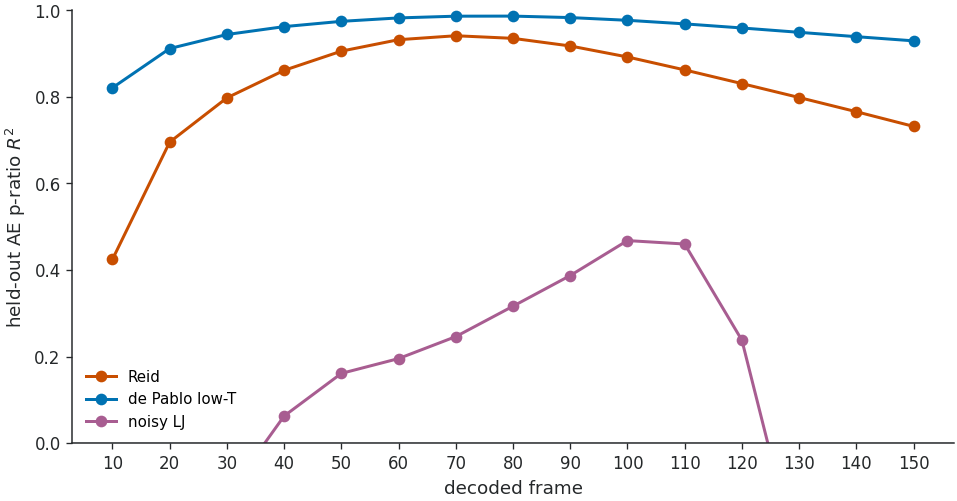

In [4]:
RECONSTRUCTION_FRAMES = list(range(10, 151, 10))
reconstruction_rows, _ = evaluate_autoencoder_reconstruction_horizons(
    result['ae'], result['test_data'], cfg=result['params'],
    normalizers=result['normalizers'], dataset=result['label'], split_name='test',
    rollout_steps=RECONSTRUCTION_FRAMES, device=DEVICE,
)
reconstruction_summary = []
for (source_key, frame), rows in reconstruction_rows.groupby(['source', 'rollout_steps'], sort=True):
    rows = rows.dropna(subset=['true_p_ratio', 'pred_p_ratio'])
    reconstruction_summary.append({
        'source': source_key, 'frame': int(frame), 'n': len(rows),
        'p_ratio_r2': r2_score(rows.true_p_ratio, rows.pred_p_ratio),
    })
reconstruction_summary = pd.DataFrame(reconstruction_summary)
display(reconstruction_summary.round(3))
fig, ax = plt.subplots(figsize=(8.0, 4.2), constrained_layout=True)
for source_key, (label, _) in DATASETS.items():
    rows = reconstruction_summary.query('source == @source_key').sort_values('frame')
    ax.plot(rows.frame, rows.p_ratio_r2, marker='o', markersize=6, lw=1.8,
            color=dataset_color(source_key), label=label)
ax.axhline(0, color=PAPER_COLORS['slate'], lw=.8)
ax.set_xticks(RECONSTRUCTION_FRAMES)
ax.set_ylim(0, 1)
style_axes(ax, xlabel='decoded frame', ylabel='held-out AE p-ratio $R^2$', legend=True)
plt.show()

In [5]:
ae = result['ae'].eval()
normalizers = result['normalizers']
test_sims = result['test_data']
rows = [(sim_index, frame) for sim_index, sim in enumerate(test_sims) for frame in range(len(sim))]
side_geometry = []
for sim in test_sims:
    side_indices = directional_side_indices_from_box(sim[0], quantile=.1)
    reference_height = float(sim[0].x[side_indices['top'], 1].mean() - sim[0].x[side_indices['bottom'], 1].mean())
    side_geometry.append((side_indices, reference_height))
latent_blocks = []
metadata_rows = []
with torch.no_grad():
    for start in range(0, len(rows), BATCH_GRAPHS):
        batch_rows = rows[start:start + BATCH_GRAPHS]
        data = batch_delta_graphs(
            test_sims, batch_rows, pos_dim=2, device=DEVICE,
            node_feature_mode='normalized_delta', edge_mode='compact_stored',
        )
        node = (data['node_feature'] - normalizers['node_feature_mean'].to(DEVICE)) / normalizers['node_feature_std'].to(DEVICE)
        edge = (data['edge_attr'] - normalizers['edge_mean'].to(DEVICE)) / normalizers['edge_std'].to(DEVICE)
        ref_edge = (data['ref_edge_attr'] - normalizers['ref_edge_mean'].to(DEVICE)) / normalizers['ref_edge_std'].to(DEVICE)
        z, _ = ae.encode(node, data['ref_pos'], edge, ref_edge, data['edge_index'], data['batch'])
        latent_blocks.append(z.cpu().numpy())
        for sim_index, frame in batch_rows:
            side_indices, reference_height = side_geometry[sim_index]
            graph = test_sims[sim_index][frame]
            current_height = float(graph.x[side_indices['top'], 1].mean() - graph.x[side_indices['bottom'], 1].mean())
            metadata_rows.append({
                'source': str(getattr(test_sims[sim_index][0], 'source_name', 'unknown')),
                'trajectory': sim_index, 'frame': frame,
                'per_frame_p_ratio': float(calc_p_ratio_rollout_sides(test_sims[sim_index], frame)),
                'side_strain_y': current_height / reference_height - 1.0,
            })
latents = np.concatenate(latent_blocks, axis=0)
latent_tensor = torch.as_tensor(latents, dtype=torch.float32)
# Built-in PyTorch PCA; q=6 retains the complete six-dimensional basis.
scores, singular_values, components = torch.pca_lowrank(latent_tensor, q=LATENT_DIM, center=True, niter=10)
pca_coordinates = (scores[:, :3] * singular_values[:3]).numpy()
latent_table = pd.DataFrame(metadata_rows)
latent_table['PC1'] = pca_coordinates[:, 0]
latent_table['PC2'] = pca_coordinates[:, 1]
latent_table['PC3'] = pca_coordinates[:, 2]
for latent_index in range(latents.shape[1]):
    latent_table[f'z{latent_index}'] = latents[:, latent_index]
explained = (singular_values[:2].square() / singular_values.square().sum()).numpy()
print({'test_frames': len(latent_table), 'pca_explained_variance': explained, 'latent_dim': latents.shape[1]})


{'test_frames': 58400, 'pca_explained_variance': array([0.7838196 , 0.21585436], dtype=float32), 'latent_dim': 6}


In [6]:
per_frame_rows, frame0_to_frame100_rows = [], []
for source_key, group in latent_table.groupby('source'):
    per_frame_rows.append({
        'source': source_key,
        'PC1 vs per-frame p-ratio': group.PC1.corr(group.per_frame_p_ratio),
        'PC2 vs per-frame p-ratio': group.PC2.corr(group.per_frame_p_ratio),
        'PC1 vs side y-strain': group.PC1.corr(group.side_strain_y),
        'PC2 vs side y-strain': group.PC2.corr(group.side_strain_y),
    })
    frame0 = group.query('frame == 0').set_index('trajectory')
    frame100 = group.query('frame == 100').set_index('trajectory')
    paired = frame0.join(frame100[['per_frame_p_ratio']], rsuffix='_frame100', how='inner')
    frame0_to_frame100_rows.append({
        'source': source_key, 'n trajectories': len(paired),
        'PC1@0 vs p-ratio@100': paired.PC1.corr(paired.per_frame_p_ratio_frame100),
        'PC2@0 vs p-ratio@100': paired.PC2.corr(paired.per_frame_p_ratio_frame100),
    })
display(pd.DataFrame(per_frame_rows).round(3))
display(pd.DataFrame(frame0_to_frame100_rows).round(3))

final_p_ratio = {trajectory: float(calc_p_ratio_rollout_sides(sim, -1)) for trajectory, sim in enumerate(test_sims)}
initial = latent_table.query('frame == 0').copy()
initial['final_p_ratio'] = initial.trajectory.map(final_p_ratio)
initial_final_rows = []
for source_key, group in initial.groupby('source'):
    correlations = {feature: group[feature].corr(group.final_p_ratio) for feature in ['PC1', 'PC2', *[f'z{i}' for i in range(LATENT_DIM)]]}
    best_latent = max((feature for feature in correlations if feature.startswith('z')), key=lambda feature: abs(correlations[feature]))
    initial_final_rows.append({
        'source': source_key, 'n trajectories': len(group),
        'PC1@0 vs final p-ratio': correlations['PC1'],
        'PC2@0 vs final p-ratio': correlations['PC2'],
        'best initial latent': best_latent,
        'best latent r': correlations[best_latent],
    })
initial_final_summary = pd.DataFrame(initial_final_rows)
display(initial_final_summary.round(3))

,source,PC1 vs per-frame p-ratio,PC2 vs per-frame p-ratio,PC1 vs side y-strain,PC2 vs side y-strain
0,depablo_low_temp,-0.347,-0.885,-0.295,-0.971
1,lj_noisy,-0.148,-0.289,-0.710,-0.304
2,reid,0.368,-0.846,0.506,-0.949


,source,n trajectories,PC1@0 vs p-ratio@100,PC2@0 vs p-ratio@100
0,depablo_low_temp,140,0.335,-0.739
1,lj_noisy,110,0.136,-0.064
2,reid,42,0.464,-0.241


,source,n trajectories,PC1@0 vs final p-ratio,PC2@0 vs final p-ratio,best initial latent,best latent r
0,depablo_low_temp,140,0.335,-0.739,z0,0.797
1,lj_noisy,110,0.122,-0.032,z2,0.140
2,reid,42,0.472,-0.256,z4,-0.511


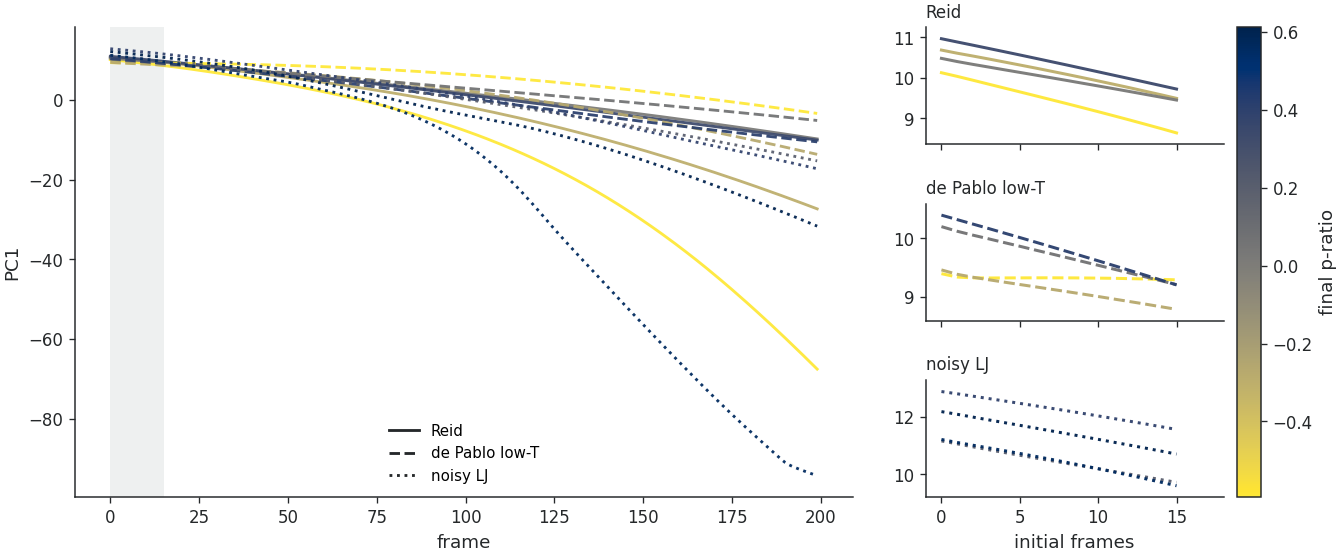

In [7]:
line_styles = {source_key: style for source_key, style in zip(DATASETS, ['-', '--', ':', '-.'])}
final_rows = pd.DataFrame([
    {'trajectory': trajectory, 'source': str(sim[0].source_name), 'final_p_ratio': float(calc_p_ratio_rollout_sides(sim, -1))}
    for trajectory, sim in enumerate(test_sims)
]).replace([np.inf, -np.inf], np.nan).dropna(subset=['final_p_ratio'])
color_values = final_rows.final_p_ratio
vmin, vmax = color_values.quantile(.01), color_values.quantile(.99)
if np.isclose(vmin, vmax):
    vmin, vmax = vmin - 1e-6, vmax + 1e-6
norm, cmap = Normalize(vmin=vmin, vmax=vmax), plt.get_cmap('cividis_r')
INITIAL_ZOOM_FRAME = 15
fig = plt.figure(figsize=(11.2, max(4.6, 1.55 * len(DATASETS))), constrained_layout=True)
grid = fig.add_gridspec(len(DATASETS), 2, width_ratios=[4.7, 1.8], hspace=.08, wspace=.06)
ax = fig.add_subplot(grid[:, 0])
zoom_axes = [fig.add_subplot(grid[row, 1]) for row in range(len(DATASETS))]
selected_trajectories = []
for source_key, (label, _) in DATASETS.items():
    available = final_rows.query('source == @source_key').sort_values('final_p_ratio').copy()
    if available.empty:
        continue
    target_values = np.linspace(available.final_p_ratio.min(), available.final_p_ratio.max(), min(4, len(available)))
    selected_indices = []
    for target in target_values:
        selected_index = (available.final_p_ratio - target).abs().idxmin()
        selected_indices.append(selected_index)
        available = available.drop(selected_index)
    for _, entry in final_rows.loc[selected_indices].sort_values('final_p_ratio').iterrows():
        trajectory = latent_table.query('trajectory == @entry.trajectory').sort_values('frame')
        color = cmap(norm(entry.final_p_ratio))
        ax.plot(trajectory.frame, trajectory.PC1, color=color, linestyle=line_styles[source_key], lw=1.7, alpha=.94)
        selected_trajectories.append((source_key, label, trajectory, color))
ax.axvspan(0, INITIAL_ZOOM_FRAME, color=PAPER_COLORS['slate'], alpha=.10, lw=0)
for source_key, (label, _) in DATASETS.items():
    ax.plot([], [], color=PAPER_COLORS['ink'], linestyle=line_styles[source_key], lw=1.7, label=label)
style_axes(ax, xlabel='frame', ylabel='PC1', legend=True)
for zoom_ax, (source_key, (label, _)) in zip(zoom_axes, DATASETS.items()):
    values = []
    for selected_source, _, trajectory, color in selected_trajectories:
        if selected_source != source_key:
            continue
        initial = trajectory.query('frame <= @INITIAL_ZOOM_FRAME')
        values.extend(initial.PC1.to_list())
        zoom_ax.plot(initial.frame, initial.PC1, color=color, linestyle=line_styles[source_key], lw=1.8, alpha=.96)
    zoom_ax.set_title(label, loc='left', fontsize=10)
    zoom_ax.set_xlim(-1, INITIAL_ZOOM_FRAME + 3)
    if values:
        low, high = min(values), max(values)
        pad = .12 * max(high - low, 1e-6)
        zoom_ax.set_ylim(low - pad, high + pad)
    style_axes(zoom_ax, xlabel='initial frames' if zoom_ax is zoom_axes[-1] else '', ylabel='', legend=False)
    if zoom_ax is not zoom_axes[-1]:
        zoom_ax.tick_params(axis='x', labelbottom=False)
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=[ax, *zoom_axes], label='final p-ratio', pad=.012, fraction=.035)
plt.show()

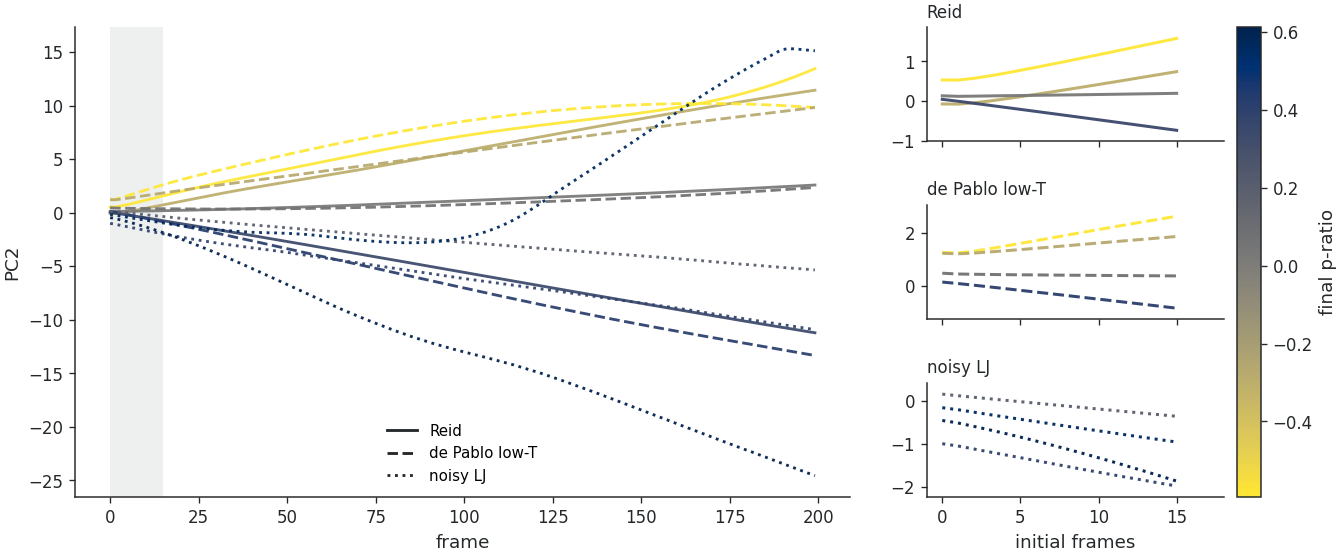

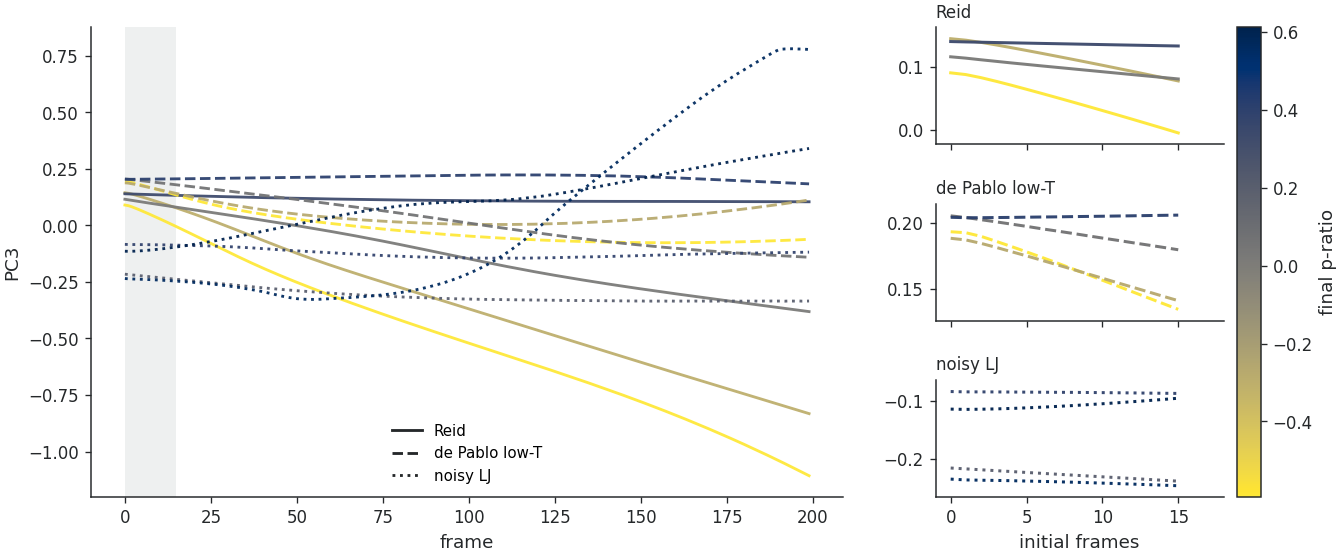

In [8]:
for component in ['PC2', 'PC3']:
    fig = plt.figure(figsize=(11.2, max(4.6, 1.55 * len(DATASETS))), constrained_layout=True)
    grid = fig.add_gridspec(len(DATASETS), 2, width_ratios=[4.7, 1.8], hspace=.08, wspace=.06)
    ax = fig.add_subplot(grid[:, 0])
    zoom_axes = [fig.add_subplot(grid[row, 1]) for row in range(len(DATASETS))]
    for source_key, _, trajectory, color in selected_trajectories:
        ax.plot(trajectory.frame, trajectory[component], color=color, linestyle=line_styles[source_key], lw=1.7, alpha=.94)
    ax.axvspan(0, INITIAL_ZOOM_FRAME, color=PAPER_COLORS['slate'], alpha=.10, lw=0)
    for source_key, (label, _) in DATASETS.items():
        ax.plot([], [], color=PAPER_COLORS['ink'], linestyle=line_styles[source_key], lw=1.7, label=label)
    style_axes(ax, xlabel='frame', ylabel=component, legend=True)
    for zoom_ax, (source_key, (label, _)) in zip(zoom_axes, DATASETS.items()):
        values = []
        for selected_source, _, trajectory, color in selected_trajectories:
            if selected_source != source_key:
                continue
            initial = trajectory.query('frame <= @INITIAL_ZOOM_FRAME')
            values.extend(initial[component].to_list())
            zoom_ax.plot(initial.frame, initial[component], color=color, linestyle=line_styles[source_key], lw=1.8, alpha=.96)
        zoom_ax.set_title(label, loc='left', fontsize=10)
        zoom_ax.set_xlim(-1, INITIAL_ZOOM_FRAME + 3)
        if values:
            low, high = min(values), max(values)
            pad = .12 * max(high - low, 1e-6)
            zoom_ax.set_ylim(low - pad, high + pad)
        style_axes(zoom_ax, xlabel='initial frames' if zoom_ax is zoom_axes[-1] else '', ylabel='', legend=False)
        if zoom_ax is not zoom_axes[-1]:
            zoom_ax.tick_params(axis='x', labelbottom=False)
    fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=[ax, *zoom_axes], label='final p-ratio', pad=.012, fraction=.035)
    plt.show()

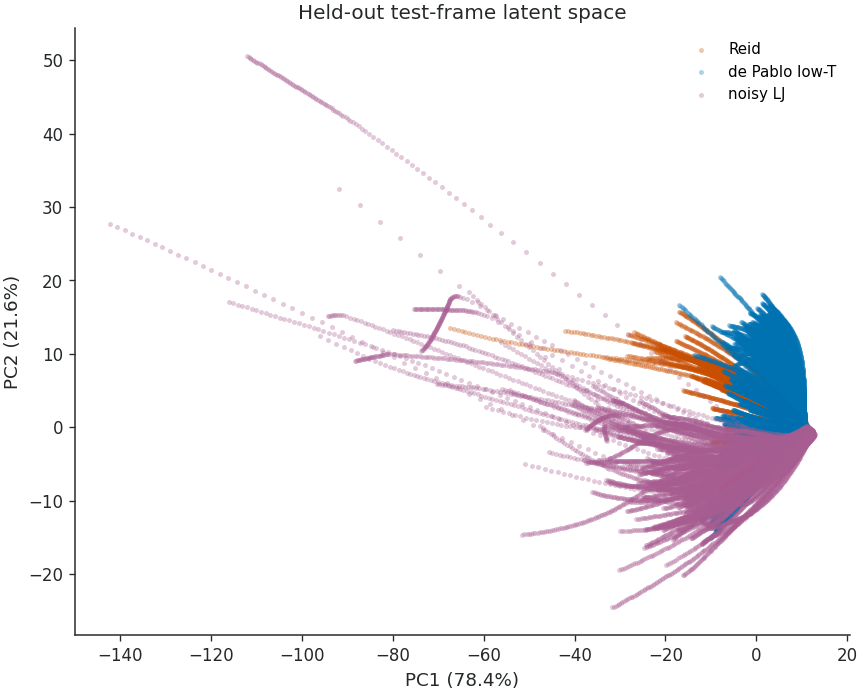

In [9]:
fig, ax = plt.subplots(figsize=(7.2, 5.8), constrained_layout=True)
for source_key, (label, _) in DATASETS.items():
    points = latent_table.query('source == @source_key')
    ax.scatter(points.PC1, points.PC2, s=9, alpha=.32, color=dataset_color(source_key), label=label, linewidths=0)
style_axes(ax, xlabel=f'PC1 ({explained[0]:.1%})', ylabel=f'PC2 ({explained[1]:.1%})', legend=True)
ax.set_title('Held-out test-frame latent space')
plt.show()
